# CranioVision — Atlas Registration & Anatomical Analysis Demo

This is the **Phase 3 Week 1** deliverable. It walks through registering a single
patient's brain MRI to the standard MNI152 space and then asking three
clinically meaningful questions about the tumor:

1. **Where in the brain is the tumor?** (Lobe, hemisphere, specific cortical regions)
2. **How close is it to eloquent cortex?** (Motor, speech, vision regions)
3. **What's the surgical risk profile?** (For pre-op planning)

**Why this matters:**  
Phase 1 told us *what* and *how big*. Phase 3 tells us *where* and *what does it threaten*.  
That's the difference between an AI segmentation tool and a clinical decision-support tool.

**Runtime:** ~5 min the first time (atlas download + 1 registration), ~30 sec on cached cases.

**Dependencies:**  
- `antspyx` (already installed)  
- `scipy` (for distance transforms)

## 1. Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import ants

from src.cranovision.config import (
    ATLAS_DIR, ATLAS_CACHE_DIR, OUTPUTS_DIR,
)
from src.cranovision.data import get_splits
from src.cranovision.atlas import (
    download_atlas_data,
    register_patient,
    load_cached_registration,
    analyze_tumor_anatomy,
    get_anatomical_summary,
    compute_eloquent_distance,
    ELOQUENT_REGIONS,
)
from src.cranovision.atlas.eloquent import get_eloquent_summary

print('Atlas data directory:', ATLAS_DIR)
print('Cache directory     :', ATLAS_CACHE_DIR)

c:\Users\hrana\anaconda3\envs\ml_env_fixed\Lib\site-packages\ignite\handlers\checkpoint.py:17: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer


Atlas data directory: D:\2_ML PROJECTS\30. Brainstorm\CranioVision\atlas_data
Cache directory     : D:\2_ML PROJECTS\30. Brainstorm\CranioVision\outputs\atlas_cache


## 2. Download atlas templates (one-time setup)

Downloads MNI152 + Harvard-Oxford to `atlas_data/`.  
Total download size: ~30 MB. Skipped if files already exist.

In [2]:
atlas_paths = download_atlas_data(verbose=True)

print('\nDownloaded files:')
for k, p in atlas_paths.items():
    size_mb = p.stat().st_size / 1e6
    print(f'  {k:<28}: {size_mb:6.1f} MB  -> {p.name}')

CranioVision — atlas template downloader
Atlas directory: D:\2_ML PROJECTS\30. Brainstorm\CranioVision\atlas_data

[skip] MNI152 1mm T1, brain-only (skull-stripped)
       (already present, 3.5 MB)

[skip] MNI152 1mm brain mask (binary)
       (already present, 0.2 MB)

[skip] Harvard-Oxford cortical atlas, max-prob 25% threshold
       (already present, 0.1 MB)

[skip] Harvard-Oxford subcortical atlas, max-prob 25% threshold
       (already present, 0.2 MB)

All atlas templates ready.

Downloaded files:
  mni152_t1_brain             :    3.5 MB  -> MNI152NLin2009cAsym_1mm_T1_brain.nii.gz
  mni152_brain_mask           :    0.2 MB  -> MNI152NLin2009cAsym_1mm_brain_mask.nii.gz
  harvard_oxford_cortical     :    0.1 MB  -> HarvardOxford-cort-maxprob-thr25-1mm.nii.gz
  harvard_oxford_subcortical  :    0.2 MB  -> HarvardOxford-sub-maxprob-thr25-1mm.nii.gz


In [3]:
from src.cranovision.atlas import ensure_atlas_aligned

aligned_paths = ensure_atlas_aligned(verbose=True)

# Verify alignment
import ants
ref = ants.image_read(str(aligned_paths['mni152_t1_brain']))
ho = ants.image_read(str(aligned_paths['harvard_oxford_cortical']))
print(f'\nReference shape: {ref.shape}')
print(f'HO cort shape  : {ho.shape}')
assert ref.shape == ho.shape, 'still mismatched!'
print('✓ Atlases aligned')

[resample] harvard_oxford_cortical
  source: HarvardOxford-cort-maxprob-thr25-1mm.nii.gz
  source shape: (182, 218, 182)
  target shape: (193, 229, 193)
  saved: HarvardOxford-cort-maxprob-thr25-1mm_resampled.nii.gz
[resample] harvard_oxford_subcortical
  source: HarvardOxford-sub-maxprob-thr25-1mm.nii.gz
  source shape: (182, 218, 182)
  target shape: (193, 229, 193)
  saved: HarvardOxford-sub-maxprob-thr25-1mm_resampled.nii.gz

Reference shape: (193, 229, 193)
HO cort shape  : (193, 229, 193)
✓ Atlases aligned


## 3. Inspect the atlas templates

Quick sanity check that the templates loaded correctly. We'll show:
- The MNI152 T1 reference brain
- The Harvard-Oxford parcellation overlaid

MNI152 T1 brain  : shape (193, 229, 193), spacing (1.0, 1.0, 1.0)
Harvard-Oxford   : shape (182, 218, 182), 49 unique labels


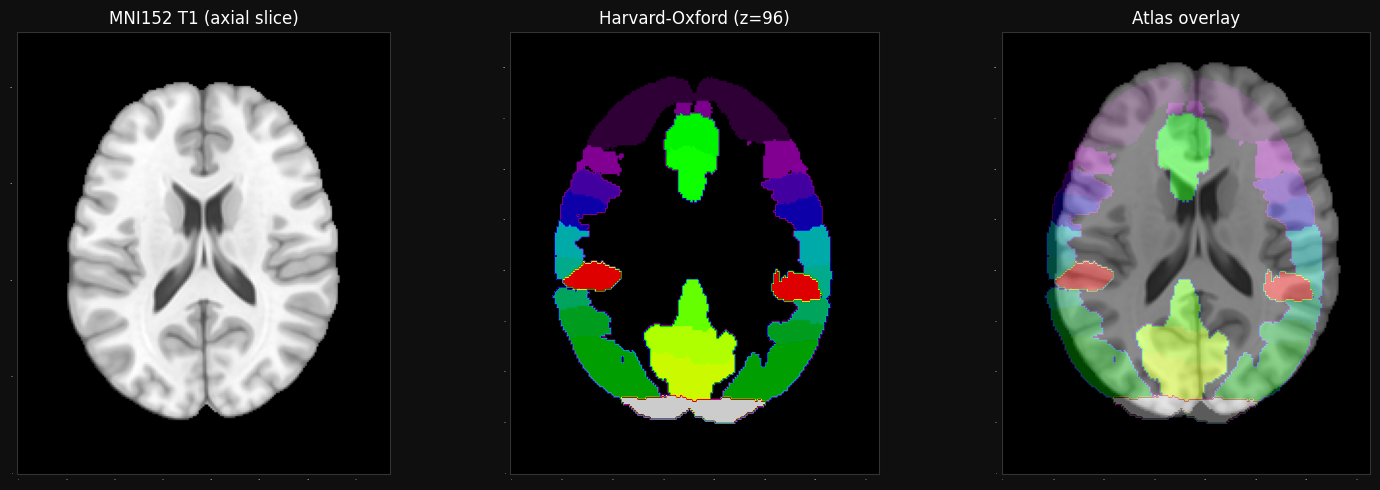

In [4]:
mni152 = ants.image_read(str(atlas_paths['mni152_t1_brain']))
ho_cort = ants.image_read(str(atlas_paths['harvard_oxford_cortical']))

print(f'MNI152 T1 brain  : shape {mni152.shape}, spacing {mni152.spacing}')
print(f'Harvard-Oxford   : shape {ho_cort.shape}, {len(np.unique(ho_cort.numpy()))} unique labels')

mni_arr = mni152.numpy()
ho_arr  = ho_cort.numpy()
z_mid = mni_arr.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('#0f0f0f')

axes[0].imshow(mni_arr[:, :, z_mid].T, cmap='gray', origin='lower')
axes[0].set_title('MNI152 T1 (axial slice)', color='white')

axes[1].imshow(ho_arr[:, :, z_mid].T, cmap='nipy_spectral', origin='lower')
axes[1].set_title(f'Harvard-Oxford (z={z_mid})', color='white')

axes[2].imshow(mni_arr[:, :, z_mid].T, cmap='gray', origin='lower')
axes[2].imshow(ho_arr[:, :, z_mid].T, cmap='nipy_spectral', origin='lower', alpha=0.45)
axes[2].set_title('Atlas overlay', color='white')

for ax in axes:
    ax.set_facecolor('#0f0f0f')
    ax.tick_params(colors='white', labelsize=0, length=0)
    for s in ax.spines.values(): s.set_edgecolor('#333')

plt.tight_layout()
plt.show()

## 4. Pick a patient case to analyze

In [5]:
_, _, test_cases = get_splits()

CASE_IDX = 0
case = test_cases[CASE_IDX]
CASE_ID = case['case_id']

# In your dataset, image is a list of 4 NIfTI paths in BraTS order:
# [t1n, t1c, t2w, t2f]. We need T1n (index 0) for registration.
t1n_path = case['image'][0]
mask_path = case['label']

print(f'Selected case: {CASE_ID}')
print(f'  T1n path    : {t1n_path}')
print(f'  GT mask     : {mask_path}')

Scanning 200 patient folders in BraTS2024_small_dataset/
  Valid cases: 200
Loading existing split from data_split.json
  Train: 140 (70%) | Val: 30 (15%) | Test: 30 (15%)
Selected case: BraTS-GLI-02196-105
  T1n path    : D:\2_ML PROJECTS\30. Brainstorm\CranioVision\data\raw\BraTS2024_small_dataset\BraTS-GLI-02196-105\BraTS-GLI-02196-105-t1n.nii
  GT mask     : D:\2_ML PROJECTS\30. Brainstorm\CranioVision\data\raw\BraTS2024_small_dataset\BraTS-GLI-02196-105\BraTS-GLI-02196-105-seg.nii


## 5. Register patient to MNI152

This is the slow step (~3-5 min on first run). Subsequent runs use cache.

**What's happening under the hood:**
1. Load patient T1 + tumor mask
2. Build 'registration mask' = healthy brain (excludes tumor + 5mm margin)
3. Run ANTs SyN: rigid -> affine -> non-linear deformation, using the registration mask
4. Apply transform to the tumor mask, putting it in MNI space
5. Save warp files to cache so we never re-run for this patient

In [6]:
result = register_patient(
    case_id=CASE_ID,
    t1_path=t1n_path,             # ← use the variable from previous cell
    tumor_mask_path=mask_path,
    use_cache=True,
    verbose=True,
)

print(f'\nFrom cache  : {result["from_cache"]}')
print(f'Cache dir   : {result["cache_dir"]}')
print(f'Warped T1   : shape {result["warped_t1"].shape}')
print(f'Warped mask : shape {result["warped_mask"].shape}')
print(f'Tumor in MNI: {int((result["warped_mask"].numpy() > 0).sum()):,} voxels')

[cache] Using cached registration for BraTS-GLI-02196-105

From cache  : True
Cache dir   : D:\2_ML PROJECTS\30. Brainstorm\CranioVision\outputs\atlas_cache\BraTS-GLI-02196-105
Warped T1   : shape (193, 229, 193)
Warped mask : shape (193, 229, 193)
Tumor in MNI: 279,268 voxels


## 6. Visualize the registration result

Before/after view — does the patient's brain now overlay cleanly with MNI152?

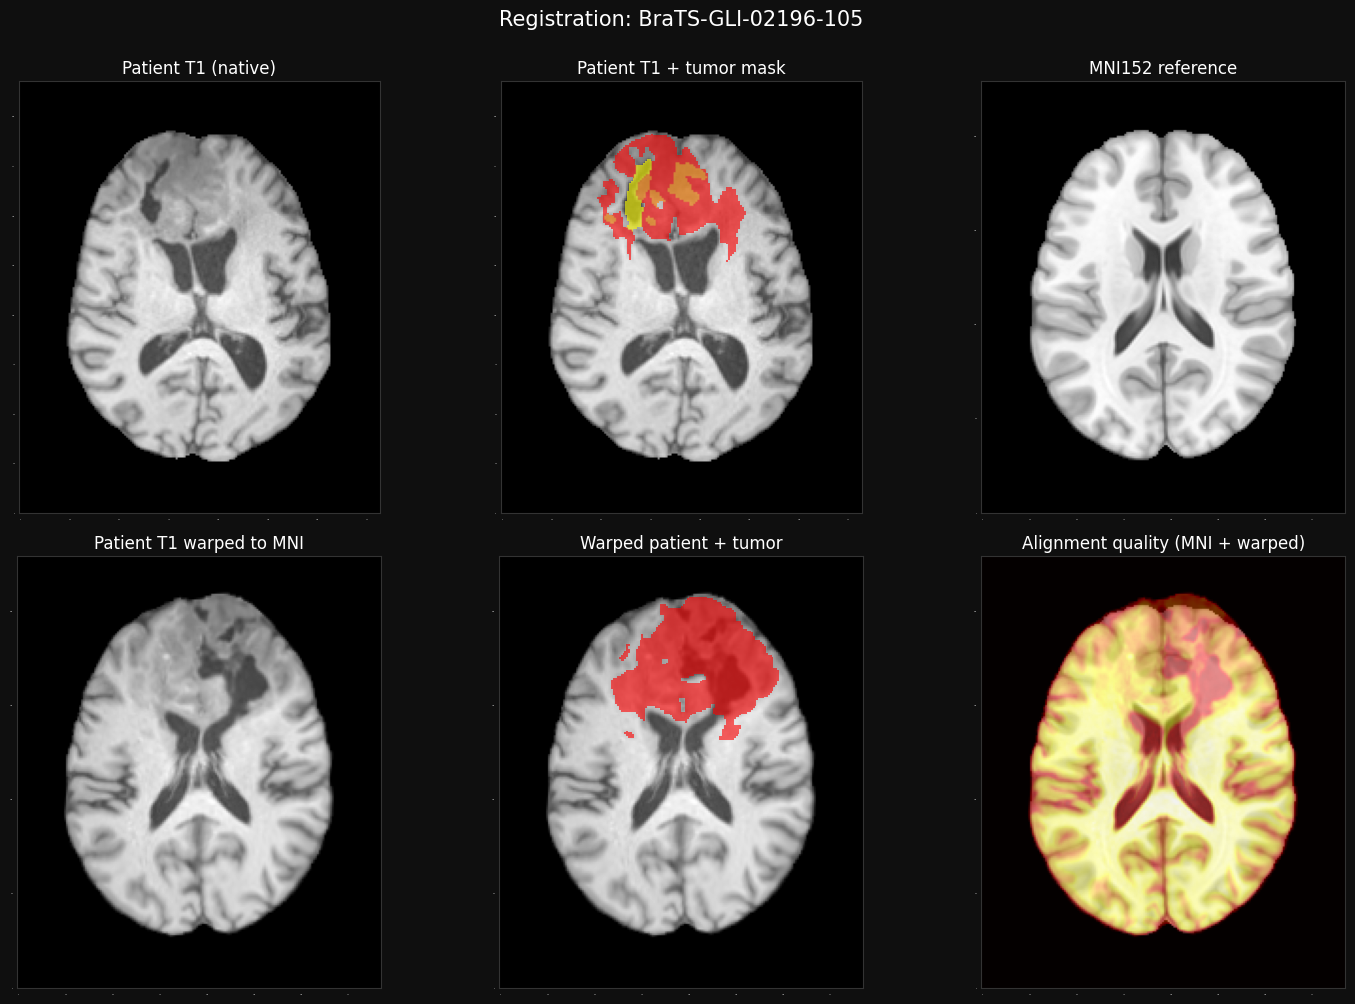

In [7]:
patient_t1   = ants.image_read(str(t1n_path))
patient_mask = ants.image_read(str(mask_path))
warped_t1    = result['warped_t1']
warped_mask  = result['warped_mask']

p_arr = patient_t1.numpy()
pm_arr = patient_mask.numpy()
w_arr = warped_t1.numpy()
wm_arr = warped_mask.numpy()
mni_arr = mni152.numpy()

# Pick informative slices
p_z = p_arr.shape[2] // 2
w_z = w_arr.shape[2] // 2

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.patch.set_facecolor('#0f0f0f')

# Top row: BEFORE registration (patient native space)
axes[0, 0].imshow(p_arr[:, :, p_z].T, cmap='gray', origin='lower')
axes[0, 0].set_title('Patient T1 (native)', color='white')

axes[0, 1].imshow(p_arr[:, :, p_z].T, cmap='gray', origin='lower')
axes[0, 1].imshow(np.where(pm_arr[:, :, p_z].T > 0, pm_arr[:, :, p_z].T, np.nan),
                   cmap='autumn', origin='lower', alpha=0.6)
axes[0, 1].set_title('Patient T1 + tumor mask', color='white')

axes[0, 2].imshow(mni_arr[:, :, w_z].T, cmap='gray', origin='lower')
axes[0, 2].set_title('MNI152 reference', color='white')

# Bottom row: AFTER registration (MNI space)
axes[1, 0].imshow(w_arr[:, :, w_z].T, cmap='gray', origin='lower')
axes[1, 0].set_title('Patient T1 warped to MNI', color='white')

axes[1, 1].imshow(w_arr[:, :, w_z].T, cmap='gray', origin='lower')
axes[1, 1].imshow(np.where(wm_arr[:, :, w_z].T > 0, wm_arr[:, :, w_z].T, np.nan),
                   cmap='autumn', origin='lower', alpha=0.6)
axes[1, 1].set_title('Warped patient + tumor', color='white')

# Overlay: warped patient over MNI to see alignment quality
axes[1, 2].imshow(mni_arr[:, :, w_z].T, cmap='gray', origin='lower')
axes[1, 2].imshow(w_arr[:, :, w_z].T, cmap='hot', origin='lower', alpha=0.45)
axes[1, 2].set_title('Alignment quality (MNI + warped)', color='white')

for ax in axes.flat:
    ax.set_facecolor('#0f0f0f')
    ax.tick_params(colors='white', labelsize=0, length=0)
    for s in ax.spines.values(): s.set_edgecolor('#333')

plt.suptitle(f'Registration: {CASE_ID}', color='white', fontsize=15, y=1.0)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / f'atlas_registration_{CASE_ID}.png', dpi=150,
             bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 7. Anatomical analysis — *where is the tumor?*

Now that the tumor mask is in MNI space, look up which Harvard-Oxford regions it occupies.

In [8]:
anatomy = analyze_tumor_anatomy(
    warped_mask=warped_mask,
    voxel_volume_mm3=1.0,    # MNI is 1mm isotropic
    top_n_regions=10,
    verbose=True,
)

print(get_anatomical_summary(anatomy))

ANATOMICAL ANALYSIS
Total tumor volume    : 279.27 cm^3
Total tumor voxels    : 279,268

Primary lobe          : Frontal Lobe  (50.1% of tumor)
Lateralization        : bilateral
  Left hemisphere     : 57.0%
  Right hemisphere    : 43.0%

Lobe distribution:
  Frontal Lobe            :  50.1%  (139,794 voxels)
  Subcortical             :  37.0%  (103,416 voxels)
  Cingulate               :   6.2%  (17,401 voxels)
  Other Cortical          :   1.0%  (2,697 voxels)
  Insular Cortex          :   0.3%  (850 voxels)

Top anatomical regions involved:
  Frontal Pole                                    :  20.7%  (57,729 voxels)
  Right Cerebral White Matter                     :  17.8%  (49,652 voxels)
  Left Cerebral White Matter                      :  17.2%  (47,967 voxels)
  Superior Frontal Gyrus                          :  10.3%  (28,812 voxels)
  Middle Frontal Gyrus                            :   8.7%  (24,332 voxels)
  Paracingulate Gyrus                             :   8.0%  (22,275 vo

### Visualize anatomical distribution

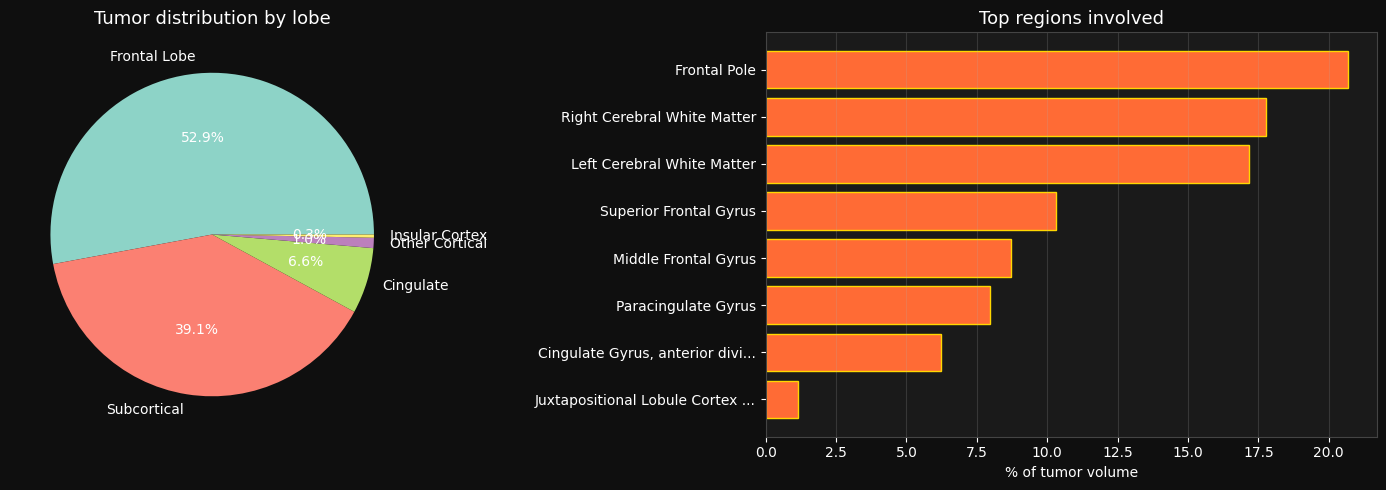

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#0f0f0f')

# Pie chart: lobe breakdown
lobes = anatomy['lobes']
if lobes:
    labels_p = list(lobes.keys())
    sizes = [lobes[l]['pct_of_tumor'] for l in labels_p]
    colors = plt.cm.Set3(np.linspace(0, 1, len(labels_p)))
    axes[0].pie(sizes, labels=labels_p, autopct='%1.1f%%',
                colors=colors, textprops={'color': 'white', 'fontsize': 10})
    axes[0].set_title('Tumor distribution by lobe', color='white', fontsize=13)
    axes[0].set_facecolor('#0f0f0f')

# Bar: top regions
regions = anatomy['regions_involved'][:8]
if regions:
    names = [r[0][:30] + ('...' if len(r[0]) > 30 else '') for r in regions]
    pcts = [r[2] for r in regions]
    y_pos = np.arange(len(names))
    axes[1].barh(y_pos, pcts, color='#FF6B35', edgecolor='#FFD700')
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels(names, color='white', fontsize=10)
    axes[1].set_xlabel('% of tumor volume', color='white')
    axes[1].set_title('Top regions involved', color='white', fontsize=13)
    axes[1].set_facecolor('#1a1a1a')
    axes[1].tick_params(colors='white')
    axes[1].invert_yaxis()
    axes[1].grid(alpha=0.2, axis='x')
    for s in axes[1].spines.values(): s.set_edgecolor('#444')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / f'atlas_anatomy_{CASE_ID}.png', dpi=150,
             bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 8. Eloquent cortex proximity — *what does the tumor threaten?*

For each clinically critical region (motor, speech, vision), compute the
minimum distance from the tumor to that region. This is what neurosurgeons
actually use to plan operations.

In [10]:
eloquent = compute_eloquent_distance(
    warped_mask=warped_mask,
    verbose=False,
)

print(get_eloquent_summary(eloquent))

ELOQUENT CORTEX PROXIMITY ANALYSIS
Region                                       Distance (mm)          Risk
------------------------------------------------------------------------
Primary Motor Cortex                              involved      [!] HIGH
Supplementary Motor Area                          involved      [!] HIGH
Broca's Area (speech production)                  involved      [!] HIGH
Primary Somatosensory Cortex                          11.4         - low
Wernicke's Area (speech comprehension)                28.3       minimal
Primary Visual Cortex                                 49.2       minimal
------------------------------------------------------------------------
Risk thresholds: HIGH <5mm,  MODERATE 5-10mm,  LOW 10-20mm,  MINIMAL >20mm

CLINICAL NOTE — Tumor is in or near eloquent cortex:
  - Primary Motor Cortex
    Function: Voluntary movement
    Risk if damaged: Hemiparesis (weakness on opposite body side)
  - Supplementary Motor Area
    Function: Movement pla

### Visualize eloquent distances

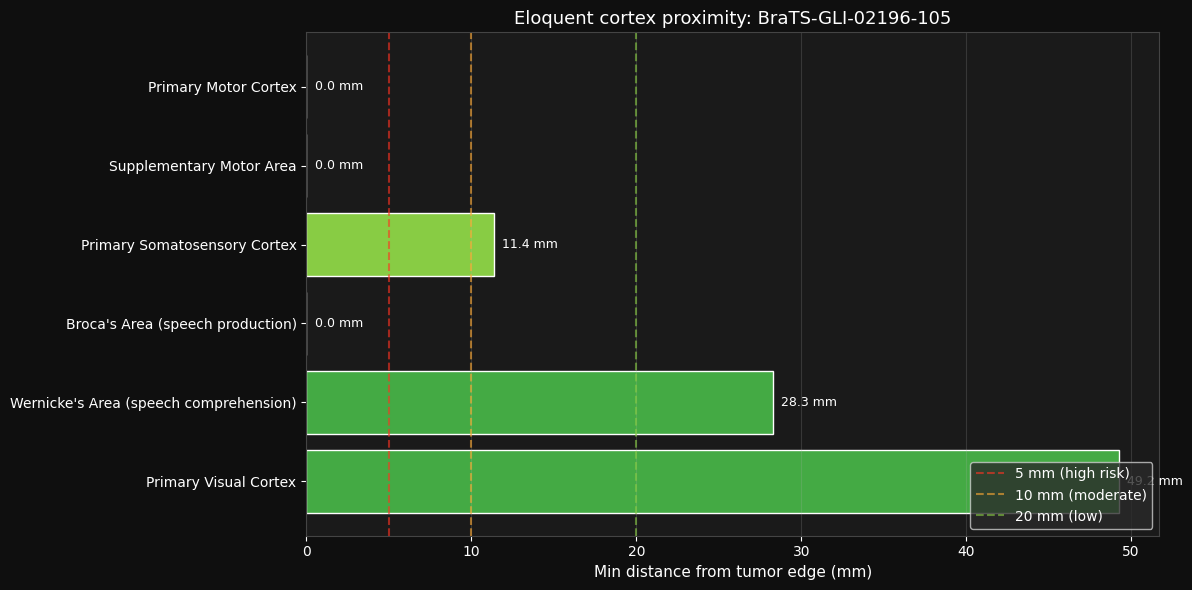

In [11]:
names = list(eloquent.keys())
distances = [eloquent[n]['distance_mm'] if not np.isinf(eloquent[n]['distance_mm']) else 100
             for n in names]
risk_levels = [eloquent[n]['risk_level'] for n in names]

risk_colors = {
    'high'    : '#FF3322',
    'moderate': '#FFAA33',
    'low'     : '#88CC44',
    'minimal' : '#44AA44',
    'unknown' : '#888888',
    'n/a'     : '#888888',
}
colors = [risk_colors[r] for r in risk_levels]

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#1a1a1a')

y_pos = np.arange(len(names))
bars = ax.barh(y_pos, distances, color=colors, edgecolor='white')

ax.axvline(x=5, color='#FF3322', linestyle='--', alpha=0.6, label='5 mm (high risk)')
ax.axvline(x=10, color='#FFAA33', linestyle='--', alpha=0.6, label='10 mm (moderate)')
ax.axvline(x=20, color='#88CC44', linestyle='--', alpha=0.6, label='20 mm (low)')

ax.set_yticks(y_pos)
ax.set_yticklabels(names, color='white', fontsize=10)
ax.set_xlabel('Min distance from tumor edge (mm)', color='white', fontsize=11)
ax.set_title(f'Eloquent cortex proximity: {CASE_ID}',
              color='white', fontsize=13)
ax.tick_params(colors='white')
ax.legend(facecolor='#2a2a2a', labelcolor='white', loc='lower right')
ax.grid(alpha=0.2, axis='x')
ax.invert_yaxis()
for s in ax.spines.values(): s.set_edgecolor('#444')

# Annotate values on bars
for i, (bar, d) in enumerate(zip(bars, distances)):
    label = f'{d:.1f} mm' if d < 100 else 'n/a'
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             label, color='white', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / f'atlas_eloquent_{CASE_ID}.png', dpi=150,
             bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 9. Save the analysis as JSON

This gets consumed by the clinical report generator (Week 3) and eventually
the frontend (Phase 4).

In [12]:
import json

atlas_report = {
    'case_id': CASE_ID,
    'registration': {
        'atlas': 'MNI152NLin2009cAsym 1mm brain',
        'parcellation': 'Harvard-Oxford max-prob 25%',
        'transform_type': 'SyN (affine + non-linear)',
        'cost_function_masking': True,
        'metadata': result['metadata'],
    },
    'anatomy': anatomy,
    'eloquent': {
        name: {
            'distance_mm': info['distance_mm'] if not np.isinf(info['distance_mm']) else None,
            'risk_level' : info['risk_level'],
            'involved'   : info['involved'],
            'function'   : info['function'],
            'deficit_if_damaged': info['deficit_if_damaged'],
        }
        for name, info in eloquent.items()
    },
}

out_path = OUTPUTS_DIR / f'atlas_report_{CASE_ID}.json'
with open(out_path, 'w') as f:
    json.dump(atlas_report, f, indent=2, default=str)

print(f'Saved: {out_path}')
print(f'\nThis JSON is ready for the Week 3 clinical report PDF.')

Saved: D:\2_ML PROJECTS\30. Brainstorm\CranioVision\outputs\atlas_report_BraTS-GLI-02196-105.json

This JSON is ready for the Week 3 clinical report PDF.


## 10. Summary — what just happened

We took a patient T1 MRI and tumor segmentation, and answered three clinical questions:

1. **Where is the tumor anatomically** -> primary lobe, top regions, lateralization
2. **What does it threaten** -> per-eloquent-region distance + risk classification
3. **What's the surgical context** -> high/moderate/low risk flags ready for the report

All outputs cached for later use, all visualizations saved to `outputs/`.

**Next steps:**  
- Week 1 wrap-up: Run the registration overnight on all 30 test cases (background task)
- Week 2: Per-model XAI extension (Grad-CAM for SwinUNETR + nnU-Net)
- Week 3: Combine atlas + XAI + ensemble into PDF clinical report